<a href="https://colab.research.google.com/github/basualdoimportante-boop/proyecto2-analisis-datos/blob/main/EDA_dataset3_agricultura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELDA 1 — Autenticación con Kaggle y Descarga del Dataset
# ============================================================

import os
import kagglehub

# Credenciales de API Heredadas (Legacy API Credentials)
os.environ['KAGGLE_USERNAME'] = 'basualdoimportante'
os.environ['KAGGLE_KEY'] = '23be7bb105d2e86189a0111926cb3fe3'

# Descarga del dataset de predicción de rendimiento agrícola
# Crop Yield Prediction using Soil and Weather
# (Predicción de Rendimiento de Cultivos usando Suelo y Clima)
path = kagglehub.dataset_download('gurudathg/crop-yield-prediction-using-soil-and-weather')

print(f"Dataset descargado en: {path}")

100%|██████████| 128k/128k [00:00<00:00, 41.2MB/s]

Extracting files...
Dataset descargado en: /root/.cache/kagglehub/datasets/gurudathg/crop-yield-prediction-using-soil-and-weather/versions/1


In [2]:
# ============================================================
# CELDA 2 — Verificar archivos disponibles
# ============================================================

import os

ruta = '/root/.cache/kagglehub/datasets/gurudathg/crop-yield-prediction-using-soil-and-weather/versions/1'

print("=== ARCHIVOS DISPONIBLES ===")
for archivo in os.listdir(ruta):
    print(archivo)

=== ARCHIVOS DISPONIBLES ===
Crop Yiled with Soil and Weather.csv


In [3]:
# ============================================================
# CELDA 3 — Carga del Dataset e Inspección Inicial
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset de rendimiento agrícola
# Nota: el nombre del archivo tiene espacios, lo escribimos exactamente igual
ruta = '/root/.cache/kagglehub/datasets/gurudathg/crop-yield-prediction-using-soil-and-weather/versions/1'
df = pd.read_csv(f'{ruta}/Crop Yiled with Soil and Weather.csv')

print("=== FORMA DEL DATASET (Shape) ===")
print(f"Filas (Rows): {df.shape[0]} | Columnas (Columns): {df.shape[1]}")

print("\n=== PRIMERAS 5 FILAS (Head) ===")
print(df.head())

print("\n=== TIPOS DE DATOS (Data Types) ===")
print(df.dtypes)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS (Descriptive Statistics) ===")
print(df.describe())

=== FORMA DEL DATASET (Shape) ===
Filas (Rows): 2596 | Columnas (Columns): 6

=== PRIMERAS 5 FILAS (Head) ===
   Fertilizer  temp     N     P     K  yeild
0        80.0  28.0  80.0  24.0  20.0   12.0
1        77.0  27.0  78.0  23.0  20.0   12.0
2        80.0  26.0  80.0  24.0  20.0   12.0
3        80.0  28.0  80.0  24.0  20.0   12.0
4        78.0  27.0  78.0  23.0  19.0   12.0

=== TIPOS DE DATOS (Data Types) ===
Fertilizer    float64
temp          float64
N             float64
P             float64
K             float64
yeild         float64
dtype: object

=== ESTADÍSTICAS DESCRIPTIVAS (Descriptive Statistics) ===
        Fertilizer         temp            N            P            K  \
count  2596.000000  2596.000000  2596.000000  2596.000000  2596.000000   
mean     66.487433    33.848237    69.522900    20.708194    17.806268   
std       9.747669     5.371279     6.802806     1.973419     1.940037   
min      49.751436    23.771310    58.839466    17.723223    14.704883   
25%    

In [4]:
# ============================================================
# CELDA 4 — Traducción de Columnas
# ============================================================

traduccion_columnas = {
    'Fertilizer': 'Fertilizante',
    'temp': 'Temperatura_Celsius',
    'N': 'Nitrogeno_Suelo',
    'P': 'Fosforo_Suelo',
    'K': 'Potasio_Suelo',
    'yeild': 'Rendimiento_Cultivo'
}

df.rename(columns=traduccion_columnas, inplace=True)

print("=== COLUMNAS TRADUCIDAS ===")
print(df.columns.tolist())

=== COLUMNAS TRADUCIDAS ===
['Fertilizante', 'Temperatura_Celsius', 'Nitrogeno_Suelo', 'Fosforo_Suelo', 'Potasio_Suelo', 'Rendimiento_Cultivo']


In [5]:
# ============================================================
# CELDA 5 — Duplicados y Valores Nulos
# ============================================================

duplicados = df.duplicated().sum()
print("=== DUPLICADOS ===")
print(f"Total de filas duplicadas: {duplicados}")

if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print(f"✓ Duplicados eliminados. Filas restantes: {len(df)}")

print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
nulos_existentes = nulos[nulos > 0]

if len(nulos_existentes) == 0:
    print("✓ No se encontraron valores nulos. El dataset está completo.")
else:
    print(nulos_existentes)

print("\n=== RESUMEN GENERAL ===")
print(f"Filas (Rows): {df.shape[0]}")
print(f"Columnas (Columns): {df.shape[1]}")
print(f"Rendimiento promedio (Average Yield): {df['Rendimiento_Cultivo'].mean():.2f} ton/ha")
print(f"Rendimiento mínimo (Minimum Yield): {df['Rendimiento_Cultivo'].min():.2f} ton/ha")
print(f"Rendimiento máximo (Maximum Yield): {df['Rendimiento_Cultivo'].max():.2f} ton/ha")

=== DUPLICADOS ===
Total de filas duplicadas: 11
✓ Duplicados eliminados. Filas restantes: 2585

=== VALORES NULOS ===
✓ No se encontraron valores nulos. El dataset está completo.

=== RESUMEN GENERAL ===
Filas (Rows): 2585
Columnas (Columns): 6
Rendimiento promedio (Average Yield): 8.53 ton/ha
Rendimiento mínimo (Minimum Yield): 5.15 ton/ha
Rendimiento máximo (Maximum Yield): 12.34 ton/ha


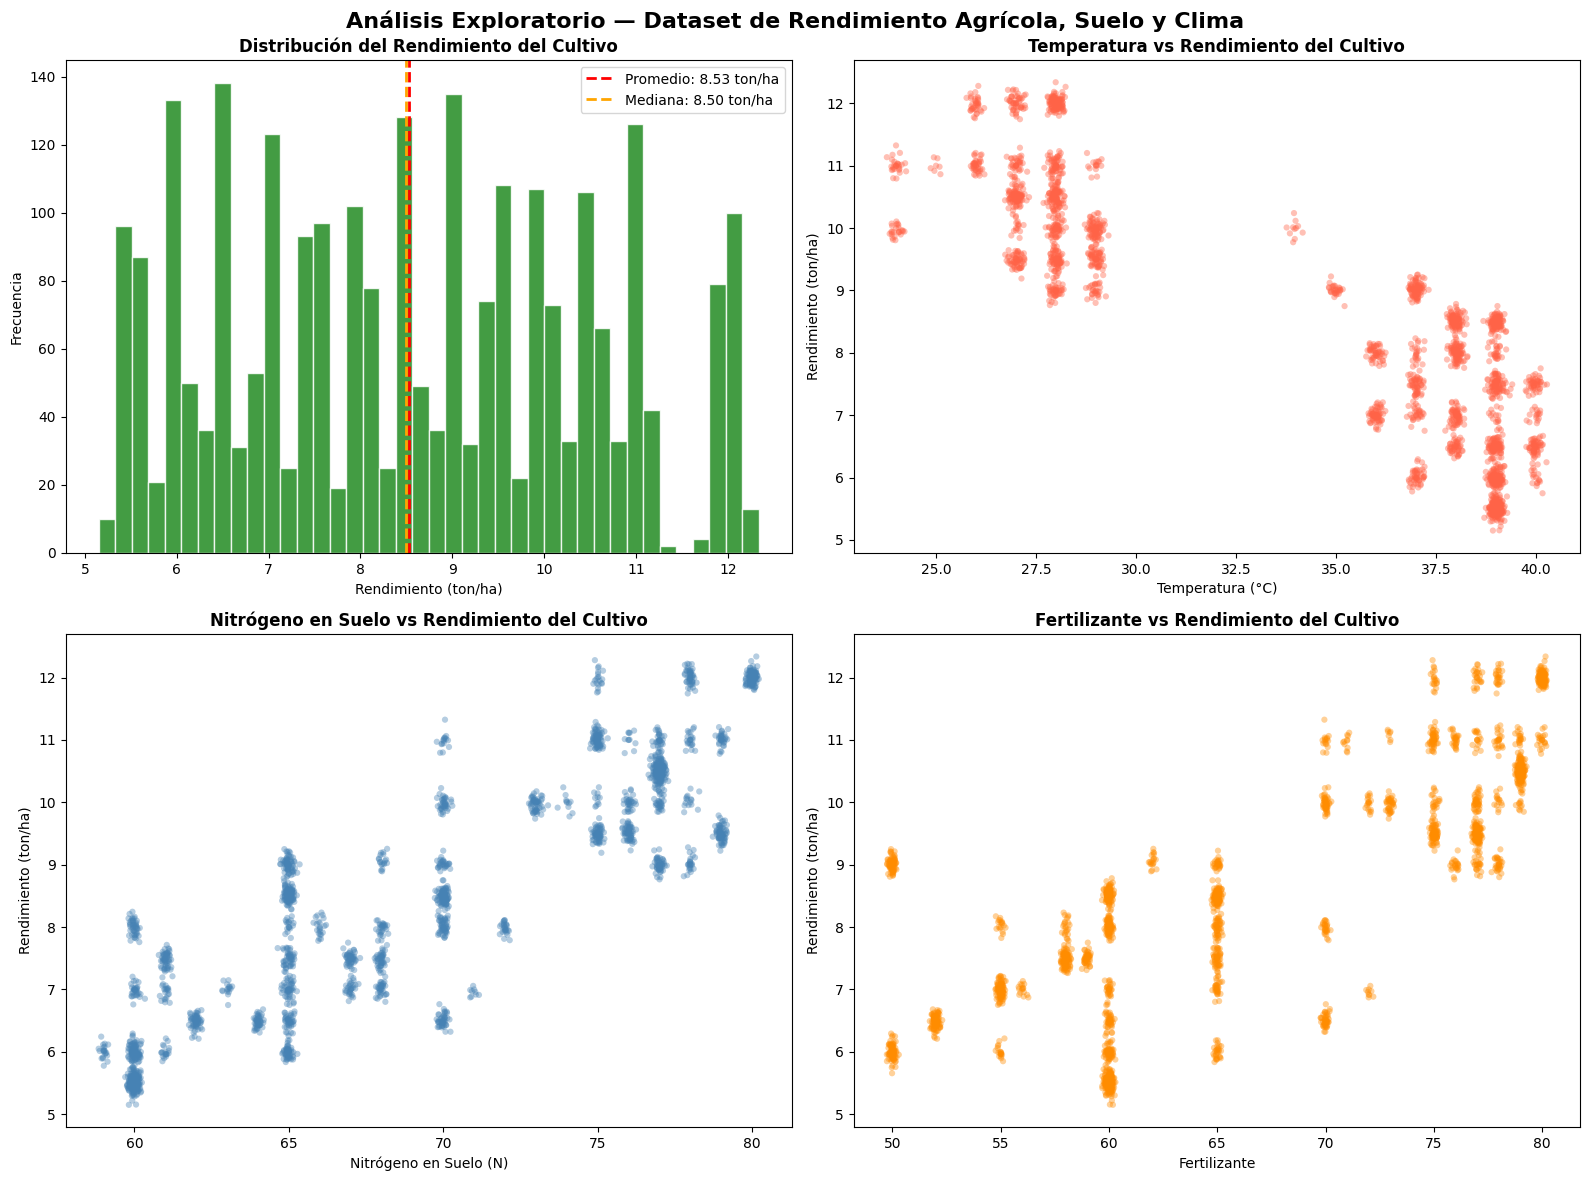

✓ Visualizaciones generadas exitosamente


In [6]:
# ============================================================
# CELDA 6 — Visualizaciones del EDA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Exploratorio — Dataset de Rendimiento Agrícola, Suelo y Clima',
             fontsize=16, fontweight='bold')

# --- GRÁFICO 1: Distribución del Rendimiento del Cultivo ---
axes[0, 0].hist(df['Rendimiento_Cultivo'], bins=40, color='forestgreen',
                edgecolor='white', alpha=0.85)
axes[0, 0].axvline(df['Rendimiento_Cultivo'].mean(), color='red', linestyle='--',
                   linewidth=2, label=f'Promedio: {df["Rendimiento_Cultivo"].mean():.2f} ton/ha')
axes[0, 0].axvline(df['Rendimiento_Cultivo'].median(), color='orange', linestyle='--',
                   linewidth=2, label=f'Mediana: {df["Rendimiento_Cultivo"].median():.2f} ton/ha')
axes[0, 0].set_title('Distribución del Rendimiento del Cultivo', fontweight='bold')
axes[0, 0].set_xlabel('Rendimiento (ton/ha)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# --- GRÁFICO 2: Temperatura vs Rendimiento (Scatter Plot) ---
axes[0, 1].scatter(df['Temperatura_Celsius'], df['Rendimiento_Cultivo'],
                   alpha=0.4, color='tomato', edgecolors='none', s=20)
axes[0, 1].set_title('Temperatura vs Rendimiento del Cultivo', fontweight='bold')
axes[0, 1].set_xlabel('Temperatura (°C)')
axes[0, 1].set_ylabel('Rendimiento (ton/ha)')

# --- GRÁFICO 3: Nitrógeno vs Rendimiento (Scatter Plot) ---
axes[1, 0].scatter(df['Nitrogeno_Suelo'], df['Rendimiento_Cultivo'],
                   alpha=0.4, color='steelblue', edgecolors='none', s=20)
axes[1, 0].set_title('Nitrógeno en Suelo vs Rendimiento del Cultivo', fontweight='bold')
axes[1, 0].set_xlabel('Nitrógeno en Suelo (N)')
axes[1, 0].set_ylabel('Rendimiento (ton/ha)')

# --- GRÁFICO 4: Fertilizante vs Rendimiento (Scatter Plot) ---
axes[1, 1].scatter(df['Fertilizante'], df['Rendimiento_Cultivo'],
                   alpha=0.4, color='darkorange', edgecolors='none', s=20)
axes[1, 1].set_title('Fertilizante vs Rendimiento del Cultivo', fontweight='bold')
axes[1, 1].set_xlabel('Fertilizante')
axes[1, 1].set_ylabel('Rendimiento (ton/ha)')

plt.tight_layout()
plt.savefig('visualizaciones_eda_agricultura.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualizaciones generadas exitosamente")

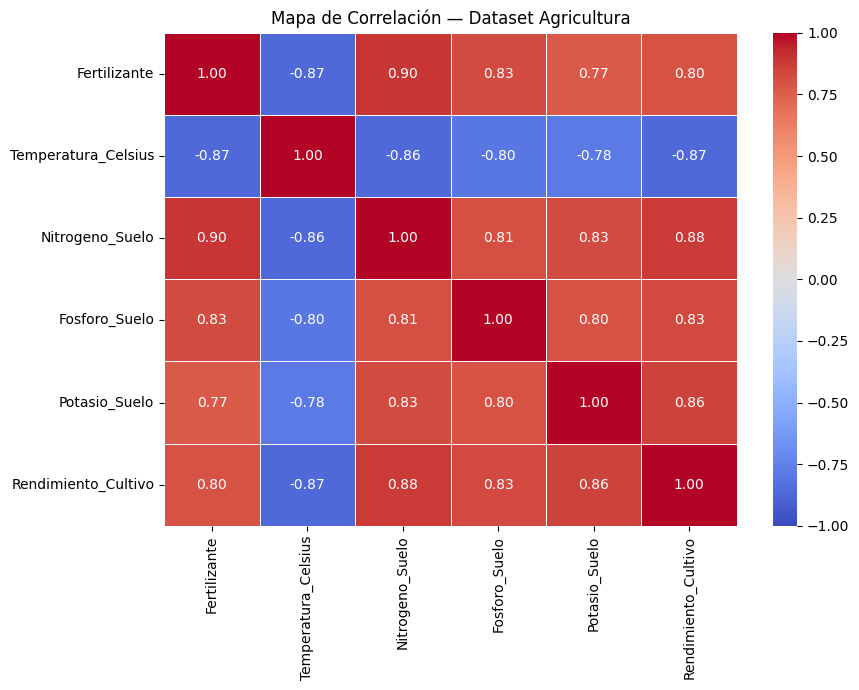

In [8]:
# ==========================================
# CELDA 7 — MAPA DE CORRELACION
# ==========================================

plt.figure(figsize=(9, 7))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Mapa de Correlación — Dataset Agricultura')
plt.tight_layout()
plt.show()

DATASET:
  2.585 registros de cultivos con mediciones de suelo,
  temperatura, fertilizante y rendimiento en ton/ha.
  Sin nulos. 11 duplicados eliminados. Dataset limpio.

HALLAZGOS CLAVE DEL MAPA DE CORRELACION:

  Nitrogeno_Suelo → Rendimiento_Cultivo: 0.88 (muy alta)
  El nitrógeno es el nutriente más determinante del
  rendimiento. A mayor nitrógeno disponible, mayor
  producción por hectárea.

  Potasio_Suelo → Rendimiento_Cultivo: 0.86 (muy alta)
  El potasio refuerza el desarrollo de la planta y
  está fuertemente asociado a buenos rendimientos.

  Fertilizante → Rendimiento_Cultivo: 0.80 (alta)
  El uso de fertilizante tiene impacto directo y
  positivo en el rendimiento del cultivo.

  Temperatura_Celsius → Rendimiento_Cultivo: -0.87 (negativa fuerte)
  Temperaturas altas perjudican el rendimiento.
  Este es el único factor con efecto negativo —
  sugiere estrés térmico en los cultivos.

CONCLUSION:
  El rendimiento agrícola está determinado principalmente
  por la composición química del suelo (N, P, K) y el
  uso de fertilizantes. La temperatura actúa como
  factor de riesgo — su efecto negativo es tan fuerte
  como el efecto positivo del nitrógeno, eso dice que la variacion termica por el calentamiento global es un factor de riesgo REAL NO IDEOLOGIA.

PROBLEMÁTICA SELECCIONADA:
  Regresión supervisada para predecir el rendimiento
  del cultivo (ton/ha) a partir de variables de suelo,
  temperatura y fertilización.
  Relevancia: optimizar decisiones agrícolas para
  maximizar producción y reducir pérdidas por clima.
  Decisiones politicas para fortalecer la seguridad alimentaria , por ejemplo quitar impuestos a fertilizantes o ayudar economicamente para que agricultores accedan a tecnologia que permitan maximizar su produccion, bajar el costo de vehiculos relacionado la agricultura ´podria mejorar el precio de productos para la poblacion en general.